<a href="https://colab.research.google.com/github/Milindkr/VGG-16-conceptual-understanding-pytorch-implementations/blob/main/VGG_16_conceptual_understanding_%26_pytorch_implementations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Introduction


VGG-16 is a deep convolutional neural network introduced by Karen Simonyan and Andrew Zisserman of the Visual Geometry Group (VGG) at Oxford University. It was presented in the landmark paper "Very Deep Convolutional Networks for Large-Scale Image Recognition" (2014) and achieved outstanding performance on the ImageNet Large Scale Visual Recognition Challenge (ILSVRC).

This notebook covers the complete story of VGG-16 — from its architectural philosophy and layer-by-layer breakdown, through its implementation in PyTorch, to practical usage in a real computer-vision project.


#Why VGG-16 Matters

##Despite being over a decade old, VGG-16 remains a go-to reference for several reasons:
- 	Architectural simplicity — uniform 3×3 conv blocks make it easy to study and extend.
- 	Excellent pretrained weights — trained on 1.2 M ImageNet images across 1000 classes.
- 	Transfer-learning workhorse — the feature extractor backbone is reused in detection, segmentation, and style-transfer pipelines.
- 	Educational clarity — its regularity makes it ideal for learning CNN design principles.


#Prerequisites


1.	Python 3.8+ and a working PyTorch ≥ 2.0 installation (CPU or CUDA).
2.	Basic familiarity with tensors, gradient descent, and classification loss.
3.	A virtual environment with torchvision, matplotlib, and tqdm installed.


In [146]:
# Quick environment check

import torch, torchvision
print(f'PyTorch  : {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')



PyTorch  : 2.10.0+cpu
torchvision: 0.25.0+cpu
CUDA available: False
Device: CPU


#2. Conceptual Overview

##The Core Idea - Depth Over Width

Prior to VGG, networks like AlexNet used large kernels (11×11, 5×5) in early layers. VGG's key insight was to replace them exclusively with 3×3 convolutions (stride 1, padding 1), stacking multiple such layers instead. This provides:




```
| Aspect              | Large Kernels (5×5)     | Stacked 3×3 Kernels              |
|---------------------|-------------------------|----------------------------------|
| Receptive field     | 5×5 = 25 px             | Two 3×3 = same 5×5 coverage      |
| Parameters          | 25 per filter           | 2 × 9 = 18 (28% fewer)           |
| Non-linearities     | 1 ReLU                  | 2 ReLUs (more expressive)        |
| Depth benefit       | None                    | Increased representational power |
```



##Building Blocks
###Convolutional Block

Each convolutional block applies: Conv2d → BatchNorm (in modern variants) → ReLU. The 3×3 kernel with padding=1 preserves spatial dimensions, so resolution only changes at pooling layers.

In [147]:
# Conceptual conv block (no BN in original VGG)
import torch.nn as nn

def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )


### Max Poolinf

After each group of conv layers, a 2×2 MaxPool2d (stride=2) halves spatial resolution. This doubles the effective receptive field while discarding fine spatial information in favour of dominant features.


###Fully Connected Head

After five pooling stages (224 → 7 spatial), three fully connected (FC) layers map the feature volume to 1000-class logits. The first two FC layers use 4096 neurons each with ReLU + Dropout(0.5).

##Receptive Field Analysis

A key concept is how deep stacking of 3×3 kernels expands the receptive field — the region of the input that influences a single output neuron:



```
| Depth (conv layers) | Receptive Field        |
|---------------------|------------------------|
| 1                   | 3 × 3                  |
| 2                   | 5 × 5                  |
| 3                   | 7 × 7                  |
| 5                   | 11 × 11                |
| 13 (full VGG-16)    | 212 × 212 (approx.)    |
```



*Insight :* A 7X7 conv uses 49 parameters per filter. Three stacked 3x3 convs achieve the same receptive field with only 3x9=27 parameters - 45% fewer - while adding two extra non-linearities.



#VGG-16 Architecture Deep Dive

##Layer-by-Layer Breakdown

- VGG-16 has 16 weight layers (13 conv + 3 FC). Input: 224×224×3 RGB image. Below is the complete layer map:



```
| Block   | Layer                          | Output Shape        | Params        |
|---------|--------------------------------|---------------------|---------------|
| Input   | —                              | 224 × 224 × 3       | —             |
| Block 1 | Conv2d(3→64) × 2               | 224 × 224 × 64      | 38,720        |
| Block 1 | MaxPool2d 2×2                  | 112 × 112 × 64      | 0             |
| Block 2 | Conv2d(64→128) × 2             | 112 × 112 × 128     | 221,440       |
| Block 2 | MaxPool2d 2×2                  | 56 × 56 × 128       | 0             |
| Block 3 | Conv2d(128→256) × 3            | 56 × 56 × 256       | 1,475,072     |
| Block 3 | MaxPool2d 2×2                  | 28 × 28 × 256       | 0             |
| Block 4 | Conv2d(256→512) × 3            | 28 × 28 × 512       | 5,899,776     |
| Block 4 | MaxPool2d 2×2                  | 14 × 14 × 512       | 0             |
| Block 5 | Conv2d(512→512) × 3            | 14 × 14 × 512       | 7,079,424     |
| Block 5 | MaxPool2d 2×2                  | 7 × 7 × 512         | 0             |
| Head    | Flatten → FC(4096)             | 4096                | 102,764,544   |
| Head    | FC(4096) → FC(4096)            | 4096                | 16,781,312    |
| Head    | FC(4096) → FC(1000)            | 1000                | 4,097,000     |
| Total   | —                              | —                   | ≈ 138.4 M     |
```
*Memory Note :-*
- 	138 M parameters means ~528 MB in float32. In practice the activations during training require several times more. A GPU with at least 6 GB VRAM is recommended for batch sizes > 16.





##Parameter Count — How to Compute It
Understanding where parameters live helps you prune or freeze selectively. For a Conv2d: params = (kernel_H × kernel_W × in_channels + 1_bias) × out_channels. For an FC: params = (in_features + 1) × out_features.




In [148]:
import torch
from torchvision.models import vgg16

model = vgg16()

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

# Per-layer breakdown
for name, module in model.named_modules():
    params = sum(p.numel() for p in module.parameters(recurse=False))
    if params > 0:
        print(f'{name:30s}  {params:>12,}')


Total parameters    : 138,357,544
Trainable parameters: 138,357,544
features.0                             1,792
features.2                            36,928
features.5                            73,856
features.7                           147,584
features.10                          295,168
features.12                          590,080
features.14                          590,080
features.17                        1,180,160
features.19                        2,359,808
features.21                        2,359,808
features.24                        2,359,808
features.26                        2,359,808
features.28                        2,359,808
classifier.0                     102,764,544
classifier.3                      16,781,312
classifier.6                       4,097,000


# PyTorch Implementation

---------------------------------------------------
This section builds VGG-16 from scratch in PyTorch, then shows how to use the pretrained torchvision version correctly.

##Building VGG-16 from Scratch

In [149]:
import torch
import torch.nn as nn

# Config: each tuple is (out_channels, 'M' for MaxPool)
CFG = [64, 64, 'M',
       128, 128, 'M',
       256, 256, 256, 'M',
       512, 512, 512, 'M',
       512, 512, 512, 'M']

def make_layers(cfg, batch_norm=False):
    layers = []
    in_c = 3
    for v in cfg:
        if v == 'M':
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            conv = nn.Conv2d(in_c, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv, nn.ReLU(inplace=True)]
            in_c = v
    return nn.Sequential(*layers)

class VGG16(nn.Module):
    def __init__(self, num_classes=1000, dropout=0.5):
        super().__init__()
        self.features   = make_layers(CFG)
        self.avgpool    = nn.AdaptiveAvgPool2d((7, 7))  # handles non-224 inputs
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)    # → (B, 512, 7, 7)
        x = self.avgpool(x)     # safe for non-224 inputs
        x = torch.flatten(x, 1) # → (B, 25088)
        x = self.classifier(x) # → (B, num_classes)
        return x

# Smoke test
model = VGG16(num_classes=10)
dummy = torch.randn(2, 3, 224, 224)
print(model(dummy).shape)  # torch.Size([2, 10])


torch.Size([2, 10])


##Using Pretrained Weights via torchvision

In [150]:
from torchvision.models import vgg16, VGG16_Weights

# Load with latest recommended weights
weights = VGG16_Weights.IMAGENET1K_V1
model   = vgg16(weights=weights)

# The weights object also carries the right preprocessing transform
preprocess = weights.transforms()   # Resize, CenterCrop, Normalize
print(preprocess)


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


ImageNet Normalization  Always normalize with mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225] when using pretrained weights. Skipping this step is one of the most common bugs in transfer-learning pipelines.

##Forward Pass & Feature Extraction

In [151]:
import torch
from PIL import Image
import requests
from io import BytesIO

# --- Load a sample image ---
url = 'https://img.freepik.com/free-photo/portrait-beautiful-purebred-pussycat-with-shorthair-orange-collar-neck-sitting-floor-reacting-camera-flash-scared-looking-light-indoor_8353-12551.jpg?semt=ais_hybrid&w=740&q=80'
img = Image.open(BytesIO(requests.get(url).content)).convert('RGB')

# --- Preprocess ---
tensor = preprocess(img).unsqueeze(0)  # (1, 3, 224, 224)

# --- Inference ---
model.eval()
with torch.no_grad():
    logits = model(tensor)             # (1, 1000)
    probs  = torch.softmax(logits, dim=1)
    top5   = probs.topk(5)

# Decode class labels
meta = weights.meta
cats = meta['categories']
for prob, idx in zip(top5.values[0], top5.indices[0]):
    print(f'{cats[idx]:40s} {prob.item()*100:.2f}%')


Egyptian cat                             83.09%
tabby                                    8.66%
tiger cat                                5.04%
bow tie                                  0.66%
lynx                                     0.33%


#Transfer Learning with VGG-16


Transfer learning adapts a pretrained network to a new task. Two common strategies are feature extraction (freeze the backbone, train only the new head) and fine-tuning (unfreeze some backbone layers and train end-to-end).



```
| Strategy                | Backbone LR | Head LR | When to Use                        |
|------------------------|------------|---------|--------------------------------------|
| Feature Extraction     | 0 (frozen) | 1e-3    | Small dataset, similar domain        |
| Fine-tuning (partial)  | 1e-5       | 1e-3    | Medium dataset, similar domain       |
| Fine-tuning (full)     | 1e-5       | 1e-4    | Large dataset, different domain      |
```



##Feature Extraction (Freeze Backbone)

In [152]:
from torchvision.models import vgg16, VGG16_Weights
import torch.nn as nn

NUM_CLASSES = 5   # e.g., 5-class flower dataset

model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

# 1. Freeze all backbone parameters
for param in model.features.parameters():
    param.requires_grad = False

# 2. Replace the classifier head
in_features = model.classifier[6].in_features  # 4096
model.classifier[6] = nn.Linear(in_features, NUM_CLASSES)

# 3. Only trainable params go to the optimizer
trainable = [p for p in model.parameters() if p.requires_grad]
print(f'Training {sum(p.numel() for p in trainable):,} / 138,357,544 params')

optimizer = torch.optim.Adam(trainable, lr=1e-3)
criterion = nn.CrossEntropyLoss()


Training 119,566,341 / 138,357,544 params


##Partial Fine-Tuning (Unfreeze Last Conv Block)

In [153]:
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Block 5 (indices 24-30 in model.features)
for layer in list(model.features.children())[24:]:
    for param in layer.parameters():
        param.requires_grad = True

# Replace head
model.classifier[6] = nn.Linear(4096, NUM_CLASSES)

# Differential learning rates
optimizer = torch.optim.SGD([
    {'params': model.features[24:].parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(),    'lr': 1e-3},
], momentum=0.9, weight_decay=1e-4)


##Training Loop

In [154]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset
import random


#Yeh check karta hai ki preprocess pehle se defined hai ya nahi. Agar nahi hai (matlab pehle wala cell nahi chala), toh khud define kar leta hai. Safety net hai yeh.
try:
    preprocess
except NameError:
    from torchvision.models import VGG16_Weights
    weights = VGG16_Weights.IMAGENET1K_V1
    preprocess = weights.transforms()

# Define a simple transform for CIFAR10, then combine with VGG's preprocess
cifar_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(), # preprocess already includes ToTensor, but keeping for clarity
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download and load CIFAR-10 dataset
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
val_dataset   = CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

# Filter CIFAR-10 to 5 classes to match NUM_CLASSES=5
# CIFAR-10 has 10 classes, we'll pick the first 5 for demonstration
selected_classes = list(range(NUM_CLASSES)) # NUM_CLASSES is 5 from previous cell

train_indices = [i for i, label in enumerate(train_dataset.targets) if label in selected_classes]
val_indices   = [i for i, label in enumerate(val_dataset.targets) if label in selected_classes]

train_dataset_filtered = Subset(train_dataset, train_indices)
val_dataset_filtered   = Subset(val_dataset, val_indices)

# For filtered datasets, remap labels to 0-4
# Create a mapping from original class labels to new 0-4 labels
label_mapping = {old_label: new_label for new_label, old_label in enumerate(selected_classes)}

class RemapLabelsDataset(torch.utils.data.Dataset):
    def __init__(self, subset_dataset, label_mapping):
        self.subset_dataset = subset_dataset
        self.label_mapping = label_mapping

    def __getitem__(self, index):
        img, original_label = self.subset_dataset[index]
        new_label = self.label_mapping[original_label]
        return img, new_label

    def __len__(self):
        return len(self.subset_dataset)

train_dataset_remapped = RemapLabelsDataset(train_dataset_filtered, label_mapping)
val_dataset_remapped   = RemapLabelsDataset(val_dataset_filtered, label_mapping)


# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset_remapped, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset_remapped, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train dataset size: {len(train_dataset_remapped)}")
print(f"Validation dataset size: {len(val_dataset_remapped)}")
print(f"Number of classes: {NUM_CLASSES}")

# Verify label range
for _, labels in train_loader:
    print(f"Min label in train_loader: {labels.min().item()}")
    print(f"Max label in train_loader: {labels.max().item()}")
    break


Train dataset size: 25000
Validation dataset size: 5000
Number of classes: 5
Min label in train_loader: 0
Max label in train_loader: 4


#Data Pipeline & Augmentation


--------------------------
A well-designed data pipeline is as important as the model itself. VGG-16 expects 224×224 RGB images normalized with ImageNet statistics.

##Standard Transforms


In [155]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ImageFolder expects: root/class_name/image.jpg
train_ds = ImageFolder('data/train', transform=train_tf)
val_ds   = ImageFolder('data/val',   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Classes : {train_ds.classes}')
print(f'Train   : {len(train_ds):,} images')
print(f'Val     : {len(val_ds):,} images')


Classes : ['class_0', 'class_1']
Train   : 10 images
Val     : 10 images


##Handling Class Imbalance

In [156]:
import torch
from torch.utils.data import WeightedRandomSampler
from collections import Counter

counts = Counter(train_ds.targets)
class_weights = {cls: 1.0/cnt for cls, cnt in counts.items()}
sample_weights = [class_weights[t] for t in train_ds.targets]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# Use sampler instead of shuffle=True
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,
                          num_workers=4, pin_memory=True)

#Feature Map Visualization
----------------------------------

Visualizing intermediate feature maps reveals what VGG-16 has learned at each stage — from low-level edges in early blocks to high-level semantic patterns in deeper blocks.



##Hooking Intermediate Activations

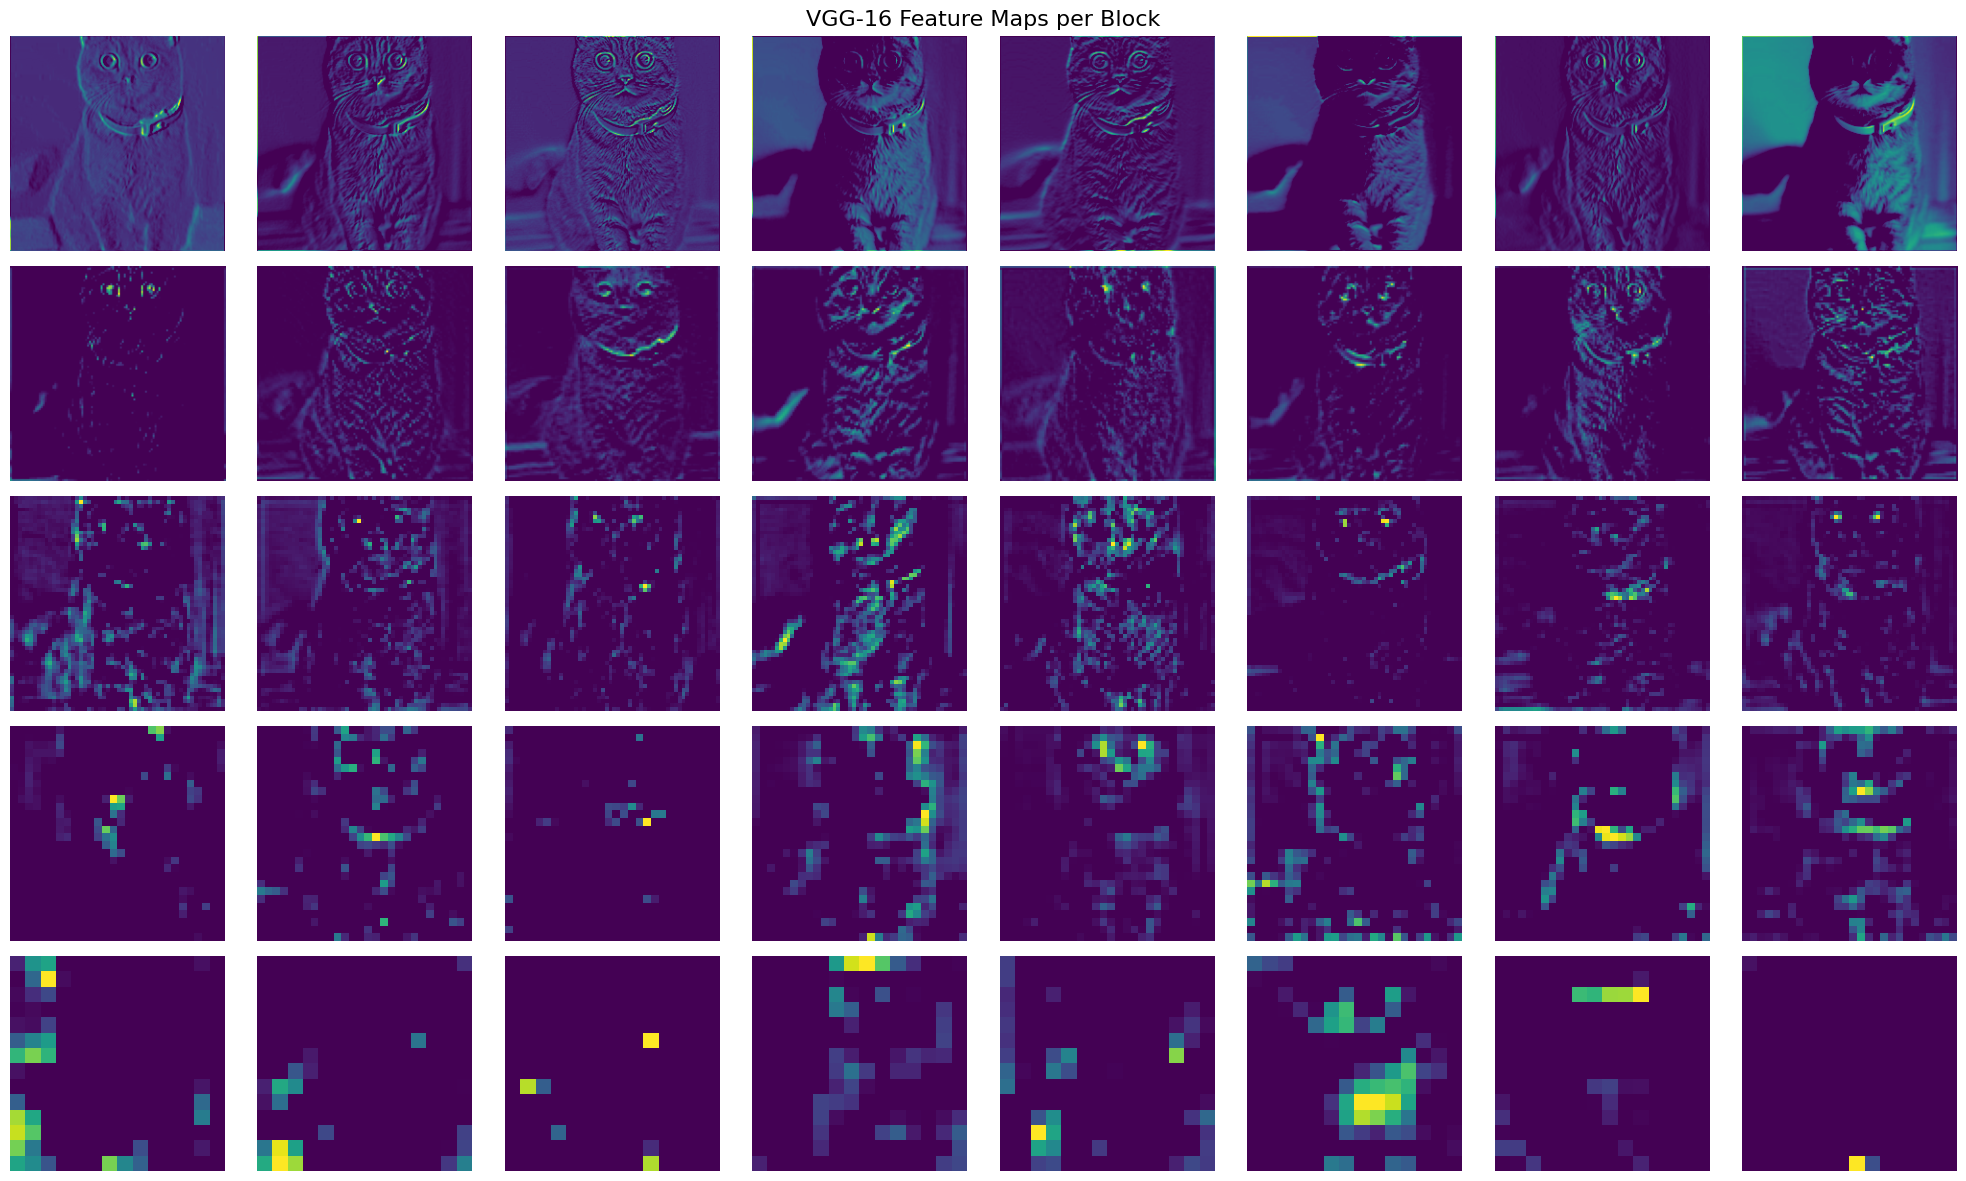

In [157]:
import matplotlib.pyplot as plt
import torch

activation = {}

def hook_fn(name):
    def fn(module, input, output):
        activation[name] = output.detach()
    return fn

# Register hooks on the first conv of each block
hooks = []
hooks.append(model.features[0].register_forward_hook(hook_fn('block1')))
hooks.append(model.features[5].register_forward_hook(hook_fn('block2')))
hooks.append(model.features[10].register_forward_hook(hook_fn('block3')))
hooks.append(model.features[17].register_forward_hook(hook_fn('block4')))
hooks.append(model.features[24].register_forward_hook(hook_fn('block5')))

# Run a single forward pass
model.eval()
with torch.no_grad():
    _ = model(tensor)

# Remove hooks
for h in hooks:
    h.remove()

# Visualize first 8 channels of each block
fig, axes = plt.subplots(5, 8, figsize=(20, 12))
fig.suptitle('VGG-16 Feature Maps per Block', fontsize=16)

for row, (name, feat) in enumerate(activation.items()):
    for col in range(8):
        ax = axes[row, col]
        ch = feat[0, col].cpu().numpy()
        ax.imshow(ch, cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(name, rotation=90, fontsize=10, labelpad=15)

plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150)
plt.show()
